## Loading packages

In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import spCLUE
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

spCLUE.fix_seed(100)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


## Loading data

In [2]:
sample_name="151671"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())

Region
Layer3    1918
Layer6     760
Layer5     721
WM         449
Layer4     245
Name: count, dtype: int64
NA spots: 17


In [4]:
# adata = spCLUE.preprocess(adata)
# adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
# g_spatia = spCLUE.prepare_graph(adata, "spatial", n_neighbors=6)
# g_expr = spCLUE.prepare_graph(adata, "expr", metric="euclidean", n_neighbors=8)
# graph_dict = {"spatial": g_spatia, "expr":g_expr}

In [5]:
from spCLUE.preprocess import (
    prepare_euclidean_graph, 
    prepare_cosine_graph, 
    prepare_fused_graph
)

# 1. 数据预处理
adata = spCLUE.preprocess(adata, hvgNumber=3000)

# 2. 构建三个视图的图
adj_s, g_spatial = prepare_euclidean_graph(adata,)
adj_f, g_feature = prepare_cosine_graph(adata, k=14)
g_combined = prepare_fused_graph(adj_s, adj_f)

# 3. 准备图字典
graph_dict = {
    "spatial": g_spatial,
    "feature": g_feature,
    "combined": g_combined,
    "adj_s": adj_s,  # 🔥 新增：保存邻接矩阵以供正则化使用
    "adj_f": adj_f,  # 🔥 新增：保存邻接矩阵以供正则化使用
}
use_zinb = True
# 如果使用ZINB解码器，需要提供raw count
if use_zinb:
    graph_dict["raw_count"] = adata.layers["raw_count"] if "raw_count" in adata.layers else adata.X.copy()

Preprocessing starting according to CSMVL description...
Selecting top 3000 HVGs...
Normalizing total counts to 10,000...
Scaling and clipping at threshold 10...


In [6]:
# 检查三个图的统计信息
def analyze_graph(adj, name):
    if sp.issparse(adj):
        adj = adj.toarray()
    
    print(f"\n=== {name} Graph Statistics ===")
    print(f"Shape: {adj.shape}")
    print(f"Edges: {(adj > 0).sum()}")
    print(f"Density: {(adj > 0).sum() / (adj.shape[0]**2) * 100:.2f}%")
    print(f"Degree min/mean/max: {adj.sum(axis=1).min():.1f} / {adj.sum(axis=1).mean():.1f} / {adj.sum(axis=1).max():.1f}")
    
    # 检查连通性
    import networkx as nx
    G = nx.from_numpy_array(adj)
    if nx.is_connected(G):
        print("Graph is connected ✓")
    else:
        components = list(nx.connected_components(G))
        print(f"Graph is NOT connected! {len(components)} components")
        print(f"Largest component size: {len(max(components, key=len))}")

# 在准备图后调用
analyze_graph(g_spatial, "Spatial")
analyze_graph(g_feature, "Feature")
analyze_graph(g_combined, "Combined")


=== Spatial Graph Statistics ===
Shape: (4110, 4110)
Edges: 213176
Density: 1.26%
Degree min/mean/max: 0.6 / 1.0 / 1.1
Graph is connected ✓

=== Feature Graph Statistics ===
Shape: (4110, 4110)
Edges: 118772
Density: 0.70%
Degree min/mean/max: 0.2 / 0.4 / 15.4
Graph is connected ✓

=== Combined Graph Statistics ===
Shape: (4110, 4110)
Edges: 325498
Density: 1.93%
Degree min/mean/max: 0.4 / 0.9 / 7.6
Graph is connected ✓


## train spCLUE

In [7]:
import scipy.sparse as sp

input_x = adata.X
if sp.issparse(input_x):
    input_x = input_x.toarray() # 将稀疏矩阵转为普通的 numpy array

spCLUE_model = spCLUE.spCLUE(
    epochs=250,
    input_data=input_x,
    graph_dict=graph_dict,
    n_clusters=n_clusters,
    lambda_ccr=0.1,  # CCR损失权重
    use_zinb=True,  # 是否使用ZINB解码器
    # kappa=0.1,
    beta=0.0,
    gamma=1.0,
    lambda_reg=0.1,      # 🔥 正则化损失权重
    reg_mode='spatial',  # 🔥 使用空间图的邻居关系
)
_, adata.obsm["spCLUE"], attention_weights = spCLUE_model.train()

Training Start (Enhanced 3-View with CCR) =========================>


 22%|██▏       | 55/250 [00:03<00:07, 24.54it/s]

epoch 50: ARI=0.0000, CCR=0.5002, CLU=2.2190, REC=0.6218, REG=0.5477


 41%|████      | 103/250 [00:05<00:05, 25.04it/s]

epoch 100: ARI=1.0000, CCR=0.4998, CLU=2.1987, REC=0.6029, REG=0.5368


...

epoch 150: ARI=1.0000, CCR=0.4996, CLU=2.1974, REC=0.5951, REG=0.5385


 82%|████████▏ | 205/250 [00:09<00:01, 24.85it/s]

epoch 200: ARI=1.0000, CCR=0.4990, CLU=2.1973, REC=0.5918, REG=0.5325


100%|██████████| 250/250 [00:11<00:00, 22.41it/s]

epoch 250: ARI=1.0000, CCR=0.4975, CLU=2.1972, REC=0.5898, REG=0.5292
Training Finished =================<


Global Mean (Averaged over features) - Spatial: -0.0405, Feature: -0.0772, Combined: -0.0544
Global Std (Averaged over features) - Spatial: 0.0254, Feature: 0.0088, Combined: 0.0066


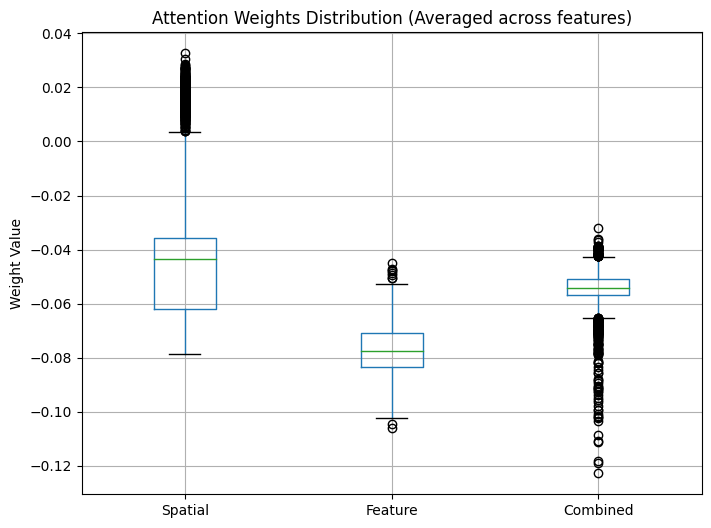

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 weights 是从模型中取出来的，先转为 numpy 数组
# weights = weights.detach().cpu().numpy() # 如果还是 tensor，需要这句
# 当前 weights 形状: [N, 3, d] (例如 3673, 3, 64)

# 【核心修改】：在特征维度 (axis=2) 上求平均，将其变回 [N, 3]
# 它的物理意义是：计算每个视图在所有特征上的“平均受关注度”
weights_2d = np.mean(attention_weights, axis=2) # 形状变为 [3673, 3]

# ----------------- 打印全局平均值 -----------------
# 此时 axis=0 对样本进行平均
mean_weights = np.mean(weights_2d, axis=0) # 形状 [3]
print(f"Global Mean (Averaged over features) - Spatial: {mean_weights[0]:.4f}, Feature: {mean_weights[1]:.4f}, Combined: {mean_weights[2]:.4f}")

std_weights = np.std(weights_2d, axis=0)
print(f"Global Std (Averaged over features) - Spatial: {std_weights[0]:.4f}, Feature: {std_weights[1]:.4f}, Combined: {std_weights[2]:.4f}")

# ----------------- 绘制图表 -----------------
# 使用降维后的 weights_2d 创建 DataFrame
df_weights = pd.DataFrame(weights_2d, columns=['Spatial', 'Feature', 'Combined'])

plt.figure(figsize=(8, 6))
# 画箱线图或小提琴图，现在不会报错了
df_weights.boxplot()  
# 或者使用 seaborn: sns.violinplot(data=df_weights)
plt.title("Attention Weights Distribution (Averaged across features)")
plt.ylabel("Weight Value")
plt.show()

In [9]:
# import torch
# import numpy as np

# # 假设 model_output 是 forward 的返回结果
# # attention_weights 是返回元组的最后一个元素
# weights = attention_weights # shape: [N, 3]

# print("=== Attention Weights Statistics ===")
# print(f"Shape: {weights.shape}")

# # 1. 检查是否有 NaN 或 Inf
# if np.isnan(weights).any() or np.isinf(weights).any():
#     print("WARNING: Weights contain NaN or Inf!")

# # 2. 检查全局平均权重 (查看模型整体偏好哪个视图)
# # Column 0: Spatial, Column 1: Feature, Column 2: Combined
# mean_weights = np.mean(weights, axis=0)
# print(f"Global Mean - Spatial: {mean_weights[0]:.4f}, Feature: {mean_weights[1]:.4f}, Combined: {mean_weights[2]:.4f}")

# # 3. 检查样本间的方差 (查看模型是否对不同细胞有不同的关注点)
# std_weights = np.std(weights, axis=0)
# print(f"Global Std  - Spatial: {std_weights[0]:.4f}, Feature: {std_weights[1]:.4f}, Combined: {std_weights[2]:.4f}")

# # 4. 检查是否归一化 (Softmax 输出的和应该接近 1)
# row_sums = np.sum(weights, axis=1)
# print(f"Row Sums (First 5): {row_sums[:5]}") # 应该全是 1.0

In [10]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # 创建 DataFrame 方便绘图
# df_weights = pd.DataFrame(weights, columns=['Spatial', 'Feature', 'Combined'])

# plt.figure(figsize=(8, 6))
# # 使用小提琴图可以看到密度分布，箱线图可以看到中位数和离群值
# sns.violinplot(data=df_weights, inner="quartile")
# plt.title("Distribution of Attention Weights per View")
# plt.ylabel("Weight Magnitude")
# plt.ylim(0, 1)  # 假设经过了 Softmax
# plt.grid(True, axis='y', linestyle='--', alpha=0.7)
# plt.show()

In [ ]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |===================================                                   |  50%

In [ ]:
adata = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151671: 0.6175904925468723


## visualization

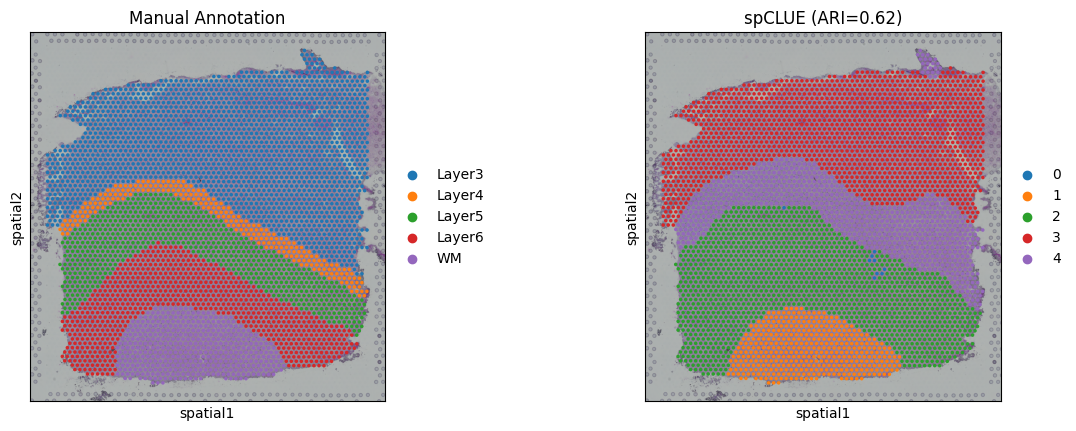

In [ ]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"spCLUE (ARI={round(ARI, 2)})"])